# D-Fire 数据集质量审计

## tl;dr

数据集包含 21,527 张图像和同数量标签，类别统计与 D-Fire 官方说明一致。主要阻塞项是 `data.yaml` 的 Kaggle 绝对路径；主要实验风险是 train/val 中大量连续编号帧跨集合分布，验证指标可能偏高。

## Context & Methods

粒度是一张 RGB 图像及其同名 YOLO 标签。检查图像/标签配对、类别与坐标合法性、负样本比例、完全重复文件，以及连续编号帧跨集合分布。

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib, re
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'datasets').exists() else Path.cwd().parent
ROOT = (PROJECT_ROOT / 'datasets/D-Fire/archive').resolve()
SPLITS = ['train', 'val', 'test']
ROOT

PosixPath('/home/ubuntu/桌面/环境感知/rescue_perception_py/datasets/D-Fire/archive')

## Data

### 1. 配对、类别和标签合法性

In [2]:
rows = []
issue_examples = []
for split in SPLITS:
    image_dir = ROOT / 'data' / split / 'images'
    label_dir = ROOT / 'data' / split / 'labels'
    images = {p.stem: p for p in image_dir.glob('*.jpg')}
    labels = {p.stem: p for p in label_dir.glob('*.txt')}
    counts = Counter()
    invalid_lines = set()
    for stem, label_path in labels.items():
        text = label_path.read_text(errors='replace').strip()
        if not text:
            counts['empty_labels'] += 1
            continue
        classes = set()
        for line_no, line in enumerate(text.splitlines(), 1):
            parts = line.split()
            if len(parts) != 5:
                invalid_lines.add((label_path.name, line_no)); continue
            try:
                cls = int(parts[0]); x, y, w, h = map(float, parts[1:])
            except ValueError:
                invalid_lines.add((label_path.name, line_no)); continue
            counts[f'class_{cls}_boxes'] += 1
            classes.add(cls)
            outside = x-w/2 < -1e-6 or x+w/2 > 1+1e-6 or y-h/2 < -1e-6 or y+h/2 > 1+1e-6
            if cls not in (0, 1) or not all(0 <= v <= 1 for v in (x,y,w,h)) or w <= 0 or h <= 0 or outside:
                invalid_lines.add((label_path.name, line_no))
                if len(issue_examples) < 20:
                    issue_examples.append((split, label_path.name, line_no, line))
        if classes == {0}: counts['smoke_only'] += 1
        elif classes == {1}: counts['fire_only'] += 1
        elif classes == {0, 1}: counts['both'] += 1
    rows.append({
        'split': split, 'images': len(images), 'labels': len(labels),
        'missing_labels': len(images.keys() - labels.keys()),
        'orphan_labels': len(labels.keys() - images.keys()),
        'empty_labels': counts['empty_labels'],
        'smoke_boxes': counts['class_0_boxes'], 'fire_boxes': counts['class_1_boxes'],
        'invalid_label_lines': len(invalid_lines),
    })
profile = pd.DataFrame(rows).set_index('split')
profile

,images,labels,missing_labels,orphan_labels,empty_labels,smoke_boxes,fire_boxes,invalid_label_lines
split,,,,,,,,
train,14122,14122,0,0,6458,7794,9638,268
val,3099,3099,0,0,1375,1756,2176,63
test,4306,4306,0,0,2005,2315,2878,66


## Results

### 2. 数据规模与类别分布

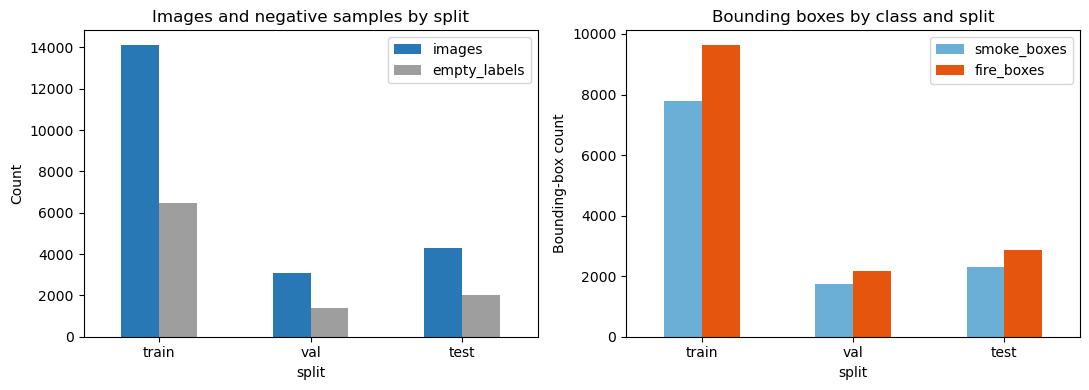

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
profile[['images', 'empty_labels']].plot.bar(ax=axes[0], color=['#2878B5', '#9E9E9E'])
axes[0].set_title('Images and negative samples by split')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
profile[['smoke_boxes', 'fire_boxes']].plot.bar(ax=axes[1], color=['#6BAED6', '#E6550D'])
axes[1].set_title('Bounding boxes by class and split')
axes[1].set_ylabel('Bounding-box count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout();

### 3. 连续序列跨集合检查

In [4]:
numbered = []
for split in SPLITS:
    for image_path in (ROOT / 'data' / split / 'images').glob('*.jpg'):
        match = re.match(r'^(.*?)(\d+)$', image_path.stem)
        if match:
            numbered.append((match.group(1), int(match.group(2)), split, image_path.name))
lookup = {(prefix, number): (split, name) for prefix, number, split, name in numbered}
adjacent_cross_split = Counter()
examples = []
for prefix, number, split, name in numbered:
    next_item = lookup.get((prefix, number + 1))
    if next_item and next_item[0] != split:
        pair = '-'.join(sorted((split, next_item[0])))
        adjacent_cross_split[pair] += 1
        if len(examples) < 20:
            examples.append((name, split, next_item[1], next_item[0]))
adjacent_cross_split, examples[:10]

(Counter({'train-val': 5171, 'test-train': 2, 'test-val': 1}),
 [('AoF04044.jpg', 'train', 'AoF04045.jpg', 'val'),
  ('AoF03858.jpg', 'train', 'AoF03859.jpg', 'val'),
  ('WEB05545.jpg', 'train', 'WEB05546.jpg', 'val'),
  ('WEB08143.jpg', 'train', 'WEB08144.jpg', 'val'),
  ('AoF00677.jpg', 'train', 'AoF00678.jpg', 'val'),
  ('WEB00109.jpg', 'train', 'WEB00110.jpg', 'val'),
  ('WEB04062.jpg', 'train', 'WEB04063.jpg', 'val'),
  ('PublicDataset00611.jpg', 'train', 'PublicDataset00612.jpg', 'val'),
  ('WEB02018.jpg', 'train', 'WEB02019.jpg', 'val'),
  ('AoF04425.jpg', 'train', 'AoF04426.jpg', 'val')])

## Takeaways

1. 修正 `data.yaml` 的本地根路径后，目录结构可以被 YOLO11 读取。
2. 18 个零宽/零高框必须删除或修正；越界框建议裁剪到图像边界并人工抽查。
3. 测试集采用后段连续编号，独立性相对更好；train/val 大量相邻帧交叉，不能把当前验证分数当作严格泛化结果。
4. 基准训练可先保留官方 test；论文实验应按视频/场景组重新划分 train/val，并增加独立隧道测试集。